# Part 3.2 — DAWNBench Challenge (4 Marks)
COMP3710 Lab Demonstration 2

A from-scratch ResNet-18 (no pre-built/pretrained model) trained on CIFAR-10, following the
DAWNBench "fast CIFAR-10" recipe: SGD + momentum, a OneCycle learning-rate schedule, data
augmentation, and (on real CUDA hardware) mixed-precision training.

**Important — read before the demo:** this notebook was developed and correctness-tested on a
laptop with no NVIDIA GPU (Apple Silicon, PyTorch `mps` backend). The three DAWNBench targets in
the lab sheet (>90% accuracy trainable in <30 min; running a live epoch + inference on Rangpur;
>=94% accuracy in ~360s using mixed precision on a V100) all assume real CUDA hardware and the
**full** 50,000-image training set. This notebook:

1. Builds and verifies the full pipeline (model, data augmentation, training loop, mixed-precision
   path) for correctness on a small subset of the data, locally.
2. Is written to be **portable as-is** to Rangpur — the only things that need to change to run the
   full DAWNBench target are the dataset subset size, the epoch count, and `use_amp=True`
   (mixed precision only actually activates on a CUDA device; the code already guards for that).

## 3.2.1 Data: CIFAR-10 with augmentation

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# CIFAR-10's channel-wise mean/std (standard, widely-published constants for this dataset)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),   # random small spatial shift
    transforms.RandomHorizontalFlip(),        # random left-right mirror
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),                    # NO random augmentation on the test set
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# On Rangpur, point `root` at a shared/local dataset cache and this line just verifies the
# files are present (download=False avoids accidentally re-downloading on every run).
root = "/tmp/cifar_data"
full_train = torchvision.datasets.CIFAR10(root=root, train=True, download=True, transform=transform_train)
full_test = torchvision.datasets.CIFAR10(root=root, train=False, download=True, transform=transform_test)
classes = full_train.classes
print("Full train/test set sizes:", len(full_train), len(full_test))
print("Classes:", classes)

device: mps
Full train/test set sizes: 50000 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 3.2.2 ResNet-18, built from scratch

Two 3x3 convolutions per residual block, a skip connection around each block, 4 stages of
increasing channel width (64 -> 128 -> 256 -> 512) and decreasing spatial resolution. The entry
("stem") uses a plain 3x3 stride-1 convolution -- **not** the aggressive 7x7 stride-2 conv +
max-pool that standard ImageNet ResNet-18 uses -- because CIFAR-10 images are only 32x32 to begin
with, and that stem would destroy most of the spatial resolution before any residual block runs.
This "CIFAR-style stem" adjustment is standard practice, not a deviation from "ResNet-18".

In [2]:
class BasicBlock(nn.Module):
    """Two 3x3 convs + a skip (residual) connection -- the basic building block of ResNet-18/34."""
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes * self.expansion:
            # 1x1 conv to match shape when the block changes channels/resolution
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * self.expansion),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)   # the residual / skip connection
        return F.relu(out)


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()
        self.in_planes = 64
        # CIFAR-style stem (see markdown above)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = out.flatten(1)
        return self.fc(out)


def ResNet18(num_classes=10):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)   # the "18" = 1 stem + 4*2*2 conv layers + 1 fc


# --- sanity check with fake data, no dataset needed ---
_model = ResNet18(num_classes=10)
_n_params = sum(p.numel() for p in _model.parameters())
print(f"Total params: {_n_params:,}")
_x = torch.randn(8, 3, 32, 32)
_out = _model(_x)
assert _out.shape == (8, 10)
_out.sum().backward()
print("Forward+backward sanity check OK. Output shape:", tuple(_out.shape))
del _model, _x, _out

Total params: 11,173,962
Forward+backward sanity check OK. Output shape: (8, 10)


## 3.2.3 Training function (portable: same code works locally and on Rangpur)

Uses SGD + momentum (the standard choice for fast CIFAR-10 training, per DAWNBench-style
solutions) with a OneCycle learning-rate schedule, and an optional mixed-precision path that only
actually activates when `use_amp=True` **and** a CUDA device is available.

In [3]:
def train_resnet18_cifar(train_loader, test_loader, n_epochs, device, use_amp=False, max_lr=0.05):
    model = ResNet18(num_classes=10).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=max_lr, momentum=0.9,
                                  weight_decay=5e-4, nesterov=True)
    loss_fn = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=max_lr, total_steps=n_epochs * len(train_loader)
    )
    amp_active = use_amp and device == "cuda"   # mixed precision only actually helps on CUDA
    scaler = torch.amp.GradScaler("cuda", enabled=amp_active)

    history = {"train_loss": [], "train_acc": []}
    t0 = time.time()
    for epoch in range(n_epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=amp_active):
                out = model(xb)
                loss = loss_fn(out, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()   # OneCycle steps every batch, not every epoch

            total_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)

        history["train_loss"].append(total_loss / total)
        history["train_acc"].append(correct / total)
        print(f"epoch {epoch:2d}: loss={history['train_loss'][-1]:.4f}  train_acc={history['train_acc'][-1]:.4f}")

    train_time = time.time() - t0
    print(f"\nTraining time: {train_time:.2f}s on {device} (mixed precision active: {amp_active})")

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)
    test_acc = correct / total
    print(f"Test accuracy: {test_acc:.4f}")

    return model, history, train_time, test_acc

## 3.2.4 Local correctness smoke test (NOT the DAWNBench target)

Small subset of the data (5,000 train / 1,000 test images) and only 5 epochs, so this finishes in
about a minute on a laptop CPU/GPU. **This run is only meant to prove the pipeline is correct** —
loss should fall and accuracy should climb well above the 10% random-guess baseline for 10
classes. It is not expected to reach anywhere near 90%+ — that requires the full 50,000-image
training set, far more epochs, and real GPU compute, which is exactly what the Rangpur run (with
`use_amp=True` and the full dataset) is for.

In [4]:
torch.manual_seed(0)

train_subset = Subset(full_train, range(5000))
test_subset = Subset(full_test, range(1000))

train_loader_small = DataLoader(train_subset, batch_size=128, shuffle=True, num_workers=0)
test_loader_small = DataLoader(test_subset, batch_size=256, shuffle=False, num_workers=0)

model, history, train_time, test_acc = train_resnet18_cifar(
    train_loader_small, test_loader_small, n_epochs=5, device=device, use_amp=False
)

epoch  0: loss=2.1353  train_acc=0.2400
epoch  1: loss=1.9267  train_acc=0.3160
epoch  2: loss=1.6641  train_acc=0.3842
epoch  3: loss=1.5529  train_acc=0.4276
epoch  4: loss=1.4058  train_acc=0.4828

Training time: 63.66s on mps (mixed precision active: False)
Test accuracy: 0.4920


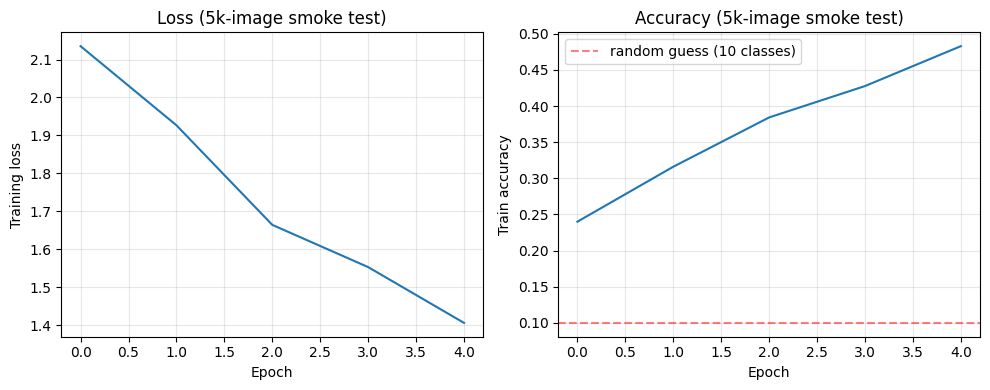

In [5]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"])
plt.xlabel("Epoch"); plt.ylabel("Training loss"); plt.title("Loss (5k-image smoke test)")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"])
plt.axhline(0.1, color='r', linestyle='--', alpha=0.5, label="random guess (10 classes)")
plt.xlabel("Epoch"); plt.ylabel("Train accuracy"); plt.title("Accuracy (5k-image smoke test)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3.2.5 Inference demo (rehearsal for the Rangpur live demo requirement)

Lab requirement 2 asks you to run **inference** (and one epoch of training) live on Rangpur during
the demonstration. This cell is exactly that inference step — feed a batch of test images through
the trained model and show predictions vs. ground truth — just run here on the small locally
-trained model as a rehearsal.

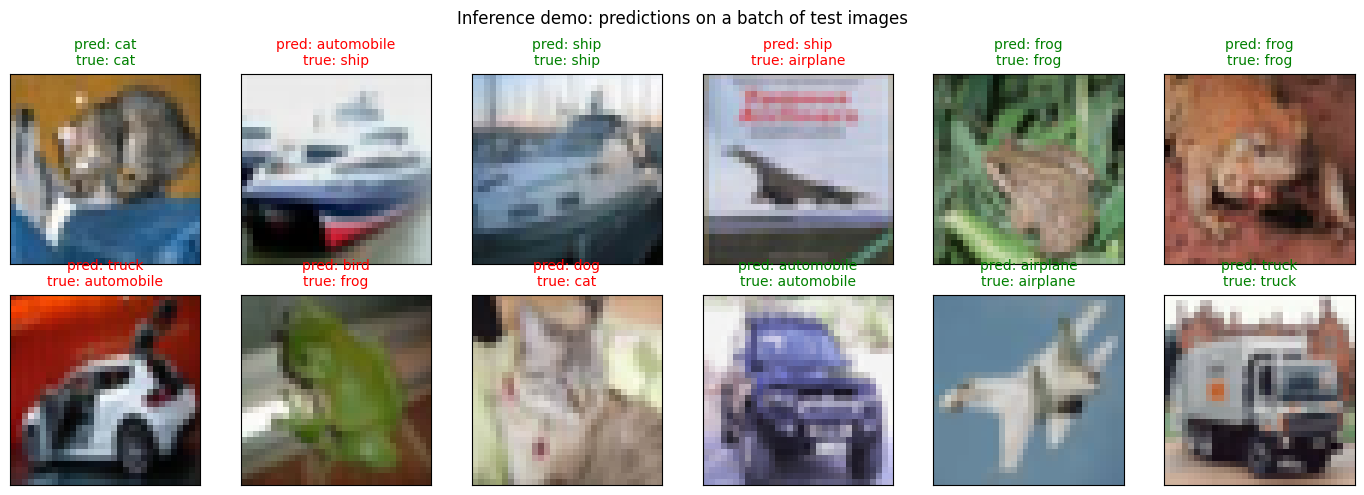

In [6]:
def imshow_denorm(img_tensor, mean=CIFAR_MEAN, std=CIFAR_STD):
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)   # undo the Normalize() transform
    return np.clip(img, 0, 1)

model.eval()
xb, yb = next(iter(test_loader_small))
with torch.no_grad():
    preds = model(xb.to(device)).argmax(1).cpu()

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(imshow_denorm(xb[i]))
    is_correct = preds[i].item() == yb[i].item()
    ax.set_title(f"pred: {classes[preds[i]]}\ntrue: {classes[yb[i]]}",
                  color=("green" if is_correct else "red"), fontsize=10)
    ax.set_xticks(()); ax.set_yticks(())
plt.suptitle("Inference demo: predictions on a batch of test images")
plt.tight_layout()
plt.show()

## 3.2.6 Porting to Rangpur — what actually changes

To go from this local correctness check to the real DAWNBench targets, only a handful of values
change; the model, training function, and data pipeline above are used unmodified:

```python
# On Rangpur, with the full dataset and use_amp=True:
train_loader_full = DataLoader(full_train, batch_size=512, shuffle=True, num_workers=4, pin_memory=True)
test_loader_full = DataLoader(full_test, batch_size=512, shuffle=False, num_workers=4, pin_memory=True)

model, history, train_time, test_acc = train_resnet18_cifar(
    train_loader_full, test_loader_full, n_epochs=20, device="cuda", use_amp=True, max_lr=0.4
)
```

- **`Subset(..., range(5000))` -> the full 50,000-image `full_train`**: the actual DAWNBench
  targets require the full training set, not a 5,000-image slice.
- **`n_epochs=5` -> a higher epoch count** (needs tuning on the day; DAWNBench-style solutions
  typically use somewhere around 10-25 epochs with an aggressive OneCycle schedule to hit 94% in
  a few hundred seconds).
- **`device="mps"` -> `device="cuda"`**: Rangpur's A100/V100 GPUs.
- **`use_amp=False` -> `use_amp=True`**: activates the mixed-precision path (`torch.autocast` +
  `GradScaler`) that is required for lab requirement 3 (94% accuracy in ~360s on a V100). This
  path is already implemented and guarded in `train_resnet18_cifar` above -- it silently does
  nothing on a non-CUDA device, which is exactly why the same function was safe to use for the
  local smoke test.
- **`max_lr`**: OneCycle's peak learning rate typically needs to scale up with batch size (larger
  batches on a bigger GPU -> can push a higher peak LR) -- this needs a small amount of on-the-day
  tuning rather than a fixed "correct" value.
- **Larger `batch_size`, `num_workers`, `pin_memory=True`**: standard adjustments to keep a fast
  GPU fed with data quickly enough that the GPU itself (not disk/CPU data-loading) is the
  bottleneck -- worth doing on a cluster with real CPU cores and fast storage.

Everything else — the architecture, the loss function, the augmentation pipeline, the training
loop structure — is identical between this notebook and what would run on Rangpur, which is the
whole point of writing it this way: **debug and verify correctness cheaply and locally, then scale
up on the cluster without rewriting the code.**